# NashFlix

A prefers a superhero movie, B a romantic comedy. Both prefer to watch a film **together** rather than alone on their smartphone.

In [ ]:
#if nashpy is not installed on colab, install it with
#!pip install nashpy

In [ ]:
# !!!! ONLY ON COLAB !!!!
# To use the jupyter books and myNashTools.py on Google Colab, 
#  you need to give access to your personal Google Drive
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')

# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/GameMatrix" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/GameMatrix'  # Change this to the path where you put the jupyter books and myNashTools.py
if my_folder not in sys.path: 
    sys.path.insert(0, my_folder)
if os.path.exists(my_folder):
    print(f"OK! the folder exists ! So you can use the jupyter books and myNashTools.py in this folder.")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)    
    # Force insertion of the folder at the beginning of the path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)        
else:
    print(f"ERROR: folder does not exist at this path. Verify the spelling or the space.")


In [1]:
#For all : Colab or your local computer :
import numpy as np, nashpy as nash, matplotlib.pyplot as plt
from myNashTools import print_equilibria, plot_indifference

## Exercise
A couple (A,B) decide to watch a movie on NashFlix.

**A** prefers a superhero movie; *B* prefers a romantic comedy. They both prefer to see a film together and not on their own smartphone.

| **A** \ *B* | *superhero* | *romcom* |
|---|---|---|
| **superhero** | (**2**, *1*) | (**0**, *0*) |
| **romcom** | (**0**, *0*) | (**1**, *2*) |

In [2]:
#in Nashpy:
A = np.array([[2, 0], [0, 1]]) #payoff from A point of view
B = np.array([[1, 0], [0, 2]]) #payoff from B point of view
game1 = nash.Game(A, B)
#just for the display of the game, we can add the names of the strategies
acts = ['superhero', 'romcom']


In [7]:
row_best = A == A.argmax(axis=0, keepdims=True)   # best row in each column

In [8]:
A.argmax(axis=0, keepdims=True)

array([[0, 1]])

In [6]:
A

array([[2, 0],
       [0, 1]])

In [4]:
row_best

array([[ True, False],
       [False,  True]])

**Q1.** Find the Nash equilibria in pure strategies.

> **Solution.**   
> **(superhero, superhero)** and **(romcom, romcom)**: in each, nobody gains by deviating alone.  
> if A chooses superhero, B's interest is to choose superhero (payoff 1 > 0), and then B is on superhero, A prefers to stay on superhero  
> if A chooses romcom, B's interest is to choose romcom (payoff 2 > 0), and then B is on romcom, A prefers to stay on romcom  
> OR another explanation
> for A : best cells in each column = (0,0), (1,1)   
> for B : best cells in each row = (0,0), (1,1)  
> $bestCellsA \cap bestCellsB = \lbrace (0,0), (1,1)\rbrace $ 


**Q2.** Find the mixed-strategy equilibrium.

> **Solution.**  
> $p$ = P(A plays superhero) is fixed by **B's** indifference: $p = 2(1-p) \Rightarrow p = 2/3$.
>
> $q$ = P(B plays superhero) is fixed by **A's** indifference: $2q = 1-q \Rightarrow q = 1/3$.
>
> Each player picks their own favourite with probability 2/3; expected payoff 2/3 each.

**Check with nashpy**

Equilibrium 1:  A -> [superhero: 1]   B -> [superhero: 1]   payoffs = (2, 1)
Equilibrium 2:  A -> [romcom: 1]   B -> [romcom: 1]   payoffs = (1, 2)
Equilibrium 3:  A -> [superhero: 2/3, romcom: 1/3]   B -> [superhero: 1/3, romcom: 2/3]   payoffs = (2/3, 2/3)


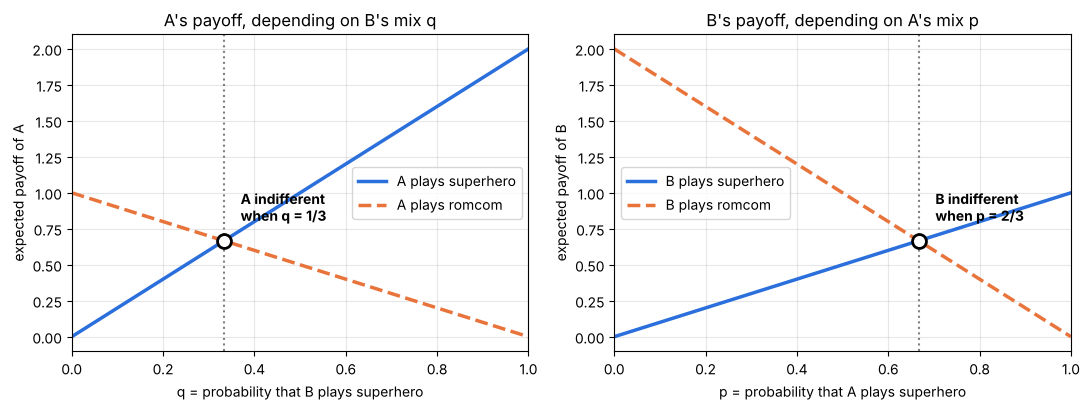

In [3]:
print_equilibria(game, acts, acts)
plot_indifference(game, acts, acts); plt.show()

**How to read the diagram.**

- **Left:** A's expected payoff for each of its two actions, depending on $q$ (how often B plays *superhero*).
  Where the line of an action is higher, A prefers that action. Where the two lines cross, A is **indifferent**.
- **Right:** the same for B, depending on $p$ (how often A plays *superhero*).

In the mixed equilibrium, each player chooses the probability that puts the **other** player exactly on the crossing point:
B plays $q$ = the crossing value of the left panel, A plays $p$ = the crossing value of the right panel.

**Q3.** What do you conclude?

> **Solution.**   
> The mixed equilibrium is *worse for both than any pure one*.   
> Theory does not say which pure equilibrium is played: they need communication, a convention or a shared random signal.  
> In fact they miss each other 5 times out of 9 : 
> 
> | **A \ B**	| **superhero (1/3)** | **romcom (2/3)** |
> |---|---|---|
> | **superhero (2/3)** | 2/3 × 1/3 = 2/9 together | 2/3 × 2/3 = 4/9 each alone | 
> | **romcom (1/3)** | 1/3 × 1/3 = 1/9 each alone | 1/3 × 2/3 = 2/9 together | 
> 
> expected value given all possibilies :   
> $E(A) = 2/9 \times 2 + 4/9 \times 0 +  1/9 \times 0 +  2/9 \times 1 = 4/9 + 2/9 = 2/3$  
> $E(B) = 2/9 \times 1 + 4/9 \times 0 +  1/9 \times 0 +  2/9 \times 2 = 2/9 + 4/9 = 2/3$
